# CytoDataFrame at a Glance

This notebook demonstrates various capabilities of
[CytoDataFrame](https://github.com/cytomining/CytoDataFrame) using examples.

CytoDataFrame is intended to provide you a Pandas-like
DataFrame experience which is enhanced with single-cell
visual information which can be viewed directly in a Jupyter notebook.

In [1]:
import pathlib

import pandas as pd

from cytodataframe.frame import CytoDataFrame

# create paths for use with CytoDataFrames below
jump_data_path = "../../../tests/data/cytotable/JUMP_plate_BR00117006"
nf1_cellpainting_path = "../../../tests/data/cytotable/NF1_cellpainting_data_shrunken/"
nuclear_speckles_path = "../../../tests/data/cytotable/nuclear_speckles"
pediatric_cancer_atlas_path = (
    "../../../tests/data/cytotable/pediatric_cancer_atlas_profiling"
)

CPU times: user 514 ms, sys: 135 ms, total: 649 ms
Wall time: 296 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Nuclei_Texture_Variance_RNA_5_03_256,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,106.035972,,,
1,1,2,33.590487,,,
2,1,3,53.527363,,,

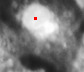
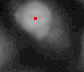
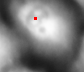
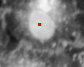
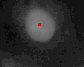
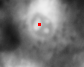
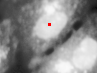
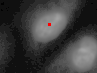
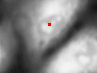

In [2]:
%%time
# view JUMP plate BR00117006 with images
frame = CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Nuclei_Texture_Variance_RNA_5_03_256",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]
frame

CPU times: user 452 ms, sys: 119 ms, total: 571 ms
Wall time: 190 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,

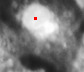
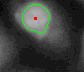
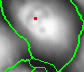
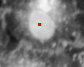
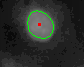
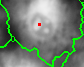
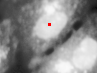
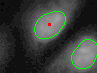
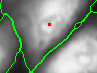

In [3]:
%%time
# view JUMP plate BR00117006 with images and overlaid outlines for segmentation
frame = CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]
frame

CPU times: user 443 ms, sys: 112 ms, total: 555 ms
Wall time: 189 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,

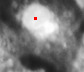
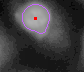
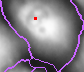
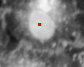
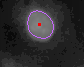
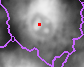
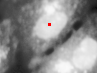
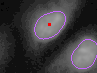
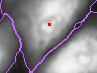

In [4]:
%%time
# view JUMP plate BR00117006 with images and overlaid outlines for segmentation
# and changing the color to something besides the default (default is green).
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
    display_options={"outline_color": (200, 100, 255)},
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 437 ms, sys: 109 ms, total: 546 ms
Wall time: 182 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,

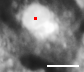
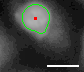
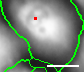
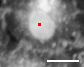
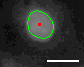
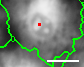
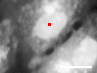
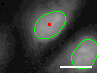
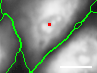

In [5]:
%%time
# view JUMP plate BR00117006 with images and overlaid outlines for segmentation
# and adding scale bars which show how micrometers scale to the pixels displayed.
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
    display_options={
        "um_per_pixel": 0.1550,
        "scale_bar": {
            "length_um": 5,
            "location": "lower right",
            "color": (255, 255, 255),
            "thickness_px": 2,
            "margin_px": 5,
        },
    },
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 465 ms, sys: 114 ms, total: 579 ms
Wall time: 195 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA,Image_Composite
0,1,1,,,,
1,1,2,,,,
2,1,3,,,,

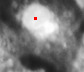
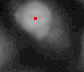
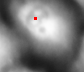
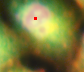
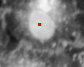
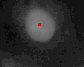
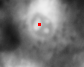
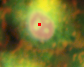
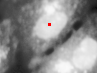
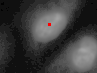
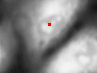
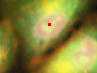

In [6]:
%%time
# view JUMP plate BR00117006 and merge multiple channels into a single
# single-cell crop composite (similar to a Fiji composite). Each channel is
# tinted a color and additively blended so colocalization is easy to see.
# Channels may be named by their column, their channel suffix (e.g. "OrigDNA"),
# or a substring. The merged image is added as a new "Image_Composite" column.
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    display_options={
        "composite_channels": {
            "OrigDNA": "blue",
            "OrigRNA": "green",
            "OrigAGP": "red",
        }
    },
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 460 ms, sys: 107 ms, total: 567 ms
Wall time: 193 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA,Image_Composite
0,1,1,,,,
1,1,2,,,,
2,1,3,,,,

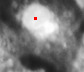
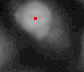
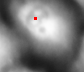
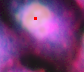
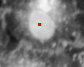
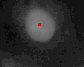
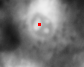
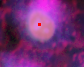
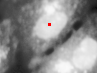
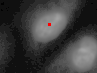
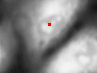
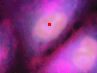

In [7]:
%%time
# the same composite feature can merge *all* image channels at once using
# default (Fiji-like) colors by passing "all".
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    display_options={"composite_channels": "all"},
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 451 ms, sys: 108 ms, total: 559 ms
Wall time: 191 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA,Image_Composite
0,1,1,,,,
1,1,2,,,,
2,1,3,,,,

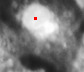
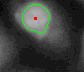
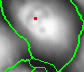
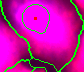
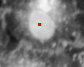
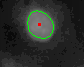
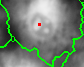
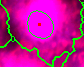
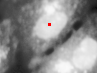
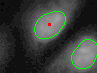
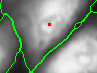
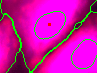

In [8]:
%%time
# composites also keep the segmentation outline and red center dot when those
# are configured, so a single merged view still shows where each object was
# segmented. Here we merge channels and overlay outlines from the segmentation
# directory (channels are colored to avoid the green outline so it stays clear).
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
    display_options={
        "composite_channels": {
            "OrigDNA": "blue",
            "OrigRNA": "magenta",
            "OrigAGP": "red",
        }
    },
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 457 ms, sys: 116 ms, total: 573 ms
Wall time: 192 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,

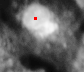
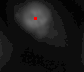
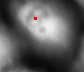
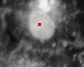
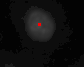
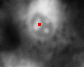
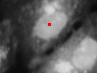
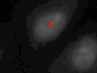
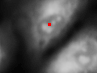

In [9]:
%%time
# view JUMP plate BR00117006 with images and adjust the brightness
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    display_options={"brightness": 10},
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 459 ms, sys: 114 ms, total: 573 ms
Wall time: 199 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,

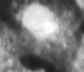
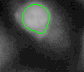
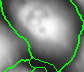
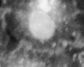
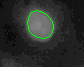
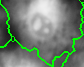
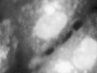
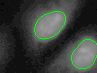
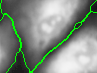

In [10]:
%%time
# view JUMP plate BR00117006 with images and overlaid outlines for segmentation
# and removing the optional red center dot.
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
    display_options={"center_dot": False},
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 463 ms, sys: 110 ms, total: 573 ms
Wall time: 193 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,

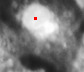
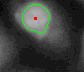
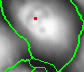
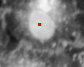
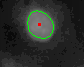
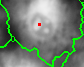
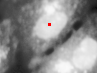
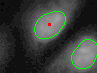
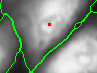

In [11]:
%%time
# view JUMP plate BR00117006 with images and change the display width
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
    display_options={"width": "100"},
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 447 ms, sys: 114 ms, total: 562 ms
Wall time: 193 ms


,0,1,2,3,4
Metadata_ImageNumber,1,1,1,1,1
Cells_Number_Object_Number,1,2,3,4,5
Image_FileName_OrigAGP,,,,,
Image_FileName_OrigDNA,,,,,
Image_FileName_OrigRNA,,,,,

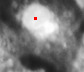
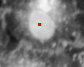
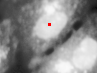
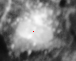
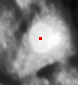
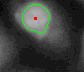
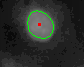
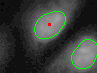
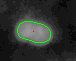
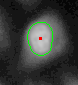
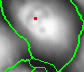
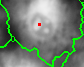
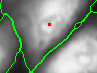
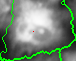
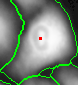

In [12]:
%%time
# view JUMP plate BR00117006 with images, change the display height and width
# and also transpose for a different view of things.
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
    display_options={"width": "200px", "height": "auto"},
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:5].T

CPU times: user 297 ms, sys: 21.8 ms, total: 319 ms
Wall time: 337 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA,Image_FileName_OrigAGP_OMEArrow_ORIG,Image_FileName_OrigAGP_OMEArrow_LABL,Image_FileName_OrigAGP_OMEArrow_COMP,Image_FileName_OrigDNA_OMEArrow_ORIG,Image_FileName_OrigDNA_OMEArrow_LABL,Image_FileName_OrigDNA_OMEArrow_COMP,Image_FileName_OrigRNA_OMEArrow_ORIG,Image_FileName_OrigRNA_OMEArrow_LABL,Image_FileName_OrigRNA_OMEArrow_COMP
0,1,1,r01c01f01p01-ch2sk1fk1fl1.tiff,r01c01f01p01-ch5sk1fk1fl1.tiff,r01c01f01p01-ch3sk1fk1fl1.tiff,,None,,,,,,,
1,1,2,r01c01f01p01-ch2sk1fk1fl1.tiff,r01c01f01p01-ch5sk1fk1fl1.tiff,r01c01f01p01-ch3sk1fk1fl1.tiff,,None,,,,,,,
2,1,3,r01c01f01p01-ch2sk1fk1fl1.tiff,r01c01f01p01-ch5sk1fk1fl1.tiff,r01c01f01p01-ch3sk1fk1fl1.tiff,,None,,,,,,,

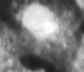
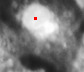
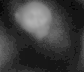
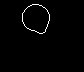
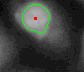
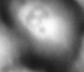
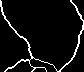
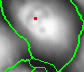
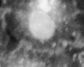
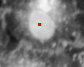
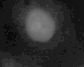
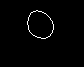
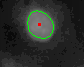
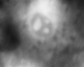
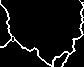
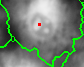
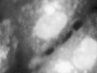
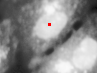
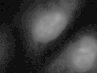
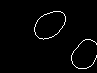
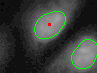
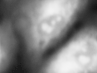
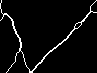
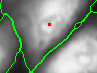

In [13]:
%%time
# export to OME Parquet, a format which uses OME Arrow
# to store OME-spec images as values within the table.
frame.to_ome_parquet(file_path="example.ome.parquet")

# read OME Parquet file into the CytoDataFrame
CytoDataFrame(data="example.ome.parquet")

CPU times: user 459 ms, sys: 111 ms, total: 570 ms
Wall time: 195 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,
3,1,4,,,
4,1,5,,,

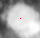
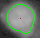
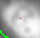
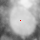
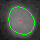
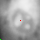
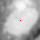
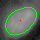
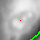
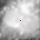
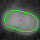
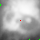
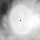
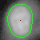
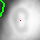

In [14]:
%%time
# view JUMP plate BR00117006 with images, changing the bounding box
# using offsets so each image has roughly the same size.
CytoDataFrame(
    data=f"{jump_data_path}/BR00117006_shrunken.parquet",
    data_context_dir=f"{jump_data_path}/images/orig",
    data_outline_context_dir=f"{jump_data_path}/images/outlines",
    display_options={
        "offset_bounding_box": {
            "x_min": -20,
            "y_min": -20,
            "x_max": 20,
            "y_max": 20,
        },
    },
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:5]

CPU times: user 440 ms, sys: 112 ms, total: 551 ms
Wall time: 187 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,
3,1,4,,,
4,1,5,,,

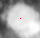
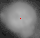
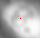
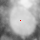
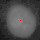
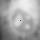
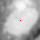
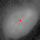
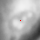
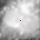
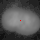
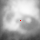
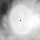
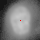
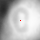

In [15]:
%%time
# CytoDataFrame can also crop images when the data does not include AreaShape
# bounding box columns (e.g. older CellProfiler outputs such as LINCS). Here we
# drop the bounding box columns to simulate this case; cropping then relies on
# offset_bounding_box applied to the compartment center coordinates.
jump_without_bounding_boxes = pd.read_parquet(
    f"{jump_data_path}/BR00117006_shrunken.parquet"
)
jump_without_bounding_boxes = jump_without_bounding_boxes.drop(
    columns=[
        column
        for column in jump_without_bounding_boxes.columns
        if "BoundingBox" in column
    ]
)
CytoDataFrame(
    data=jump_without_bounding_boxes,
    data_context_dir=f"{jump_data_path}/images/orig",
    display_options={
        "offset_bounding_box": {
            "x_min": -20,
            "y_min": -20,
            "x_max": 20,
            "y_max": 20,
        },
    },
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:5]

CPU times: user 433 ms, sys: 112 ms, total: 545 ms
Wall time: 255 ms


,Metadata_ImageNumber,Cells_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigRNA
0,1,1,,,
1,1,2,,,
2,1,3,,,

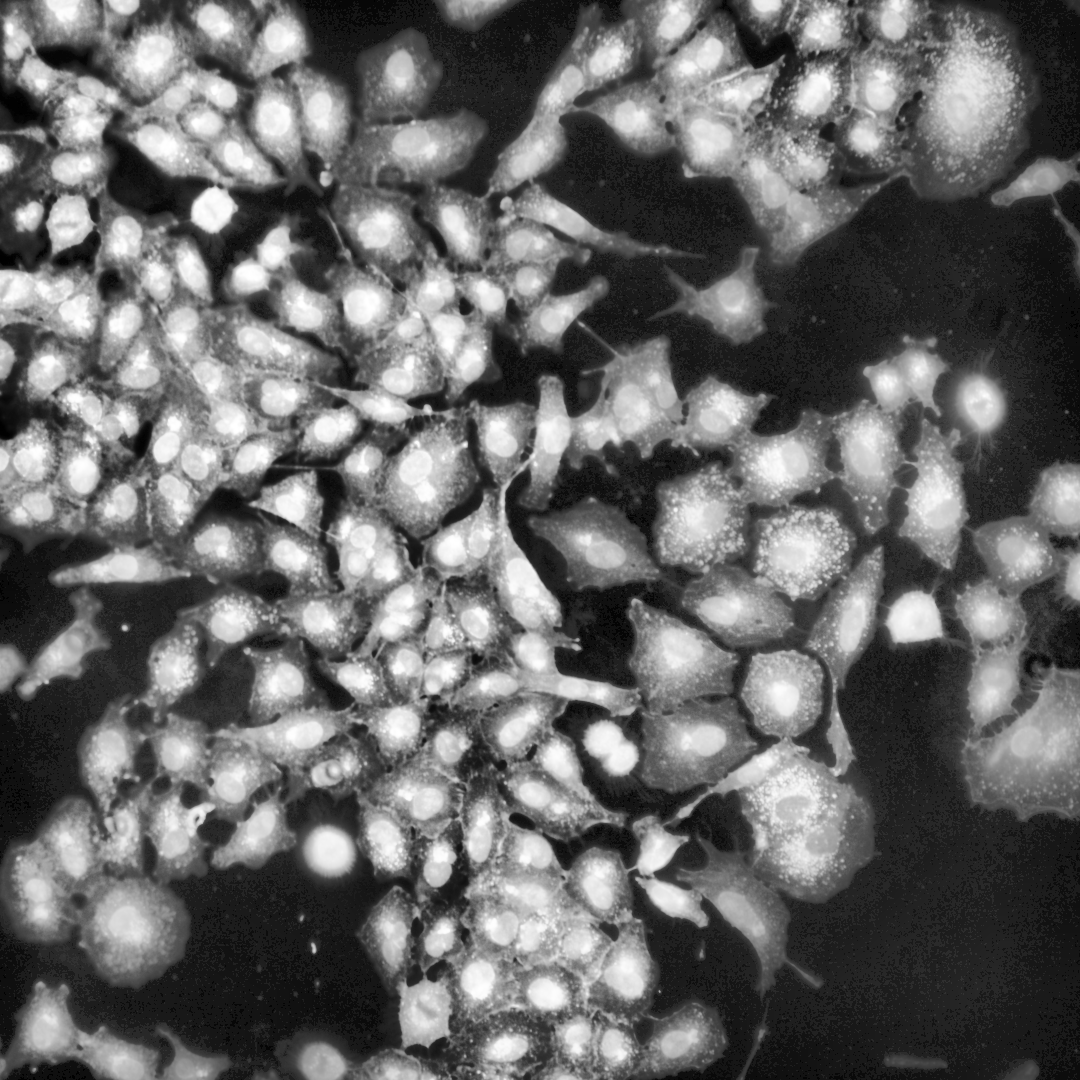
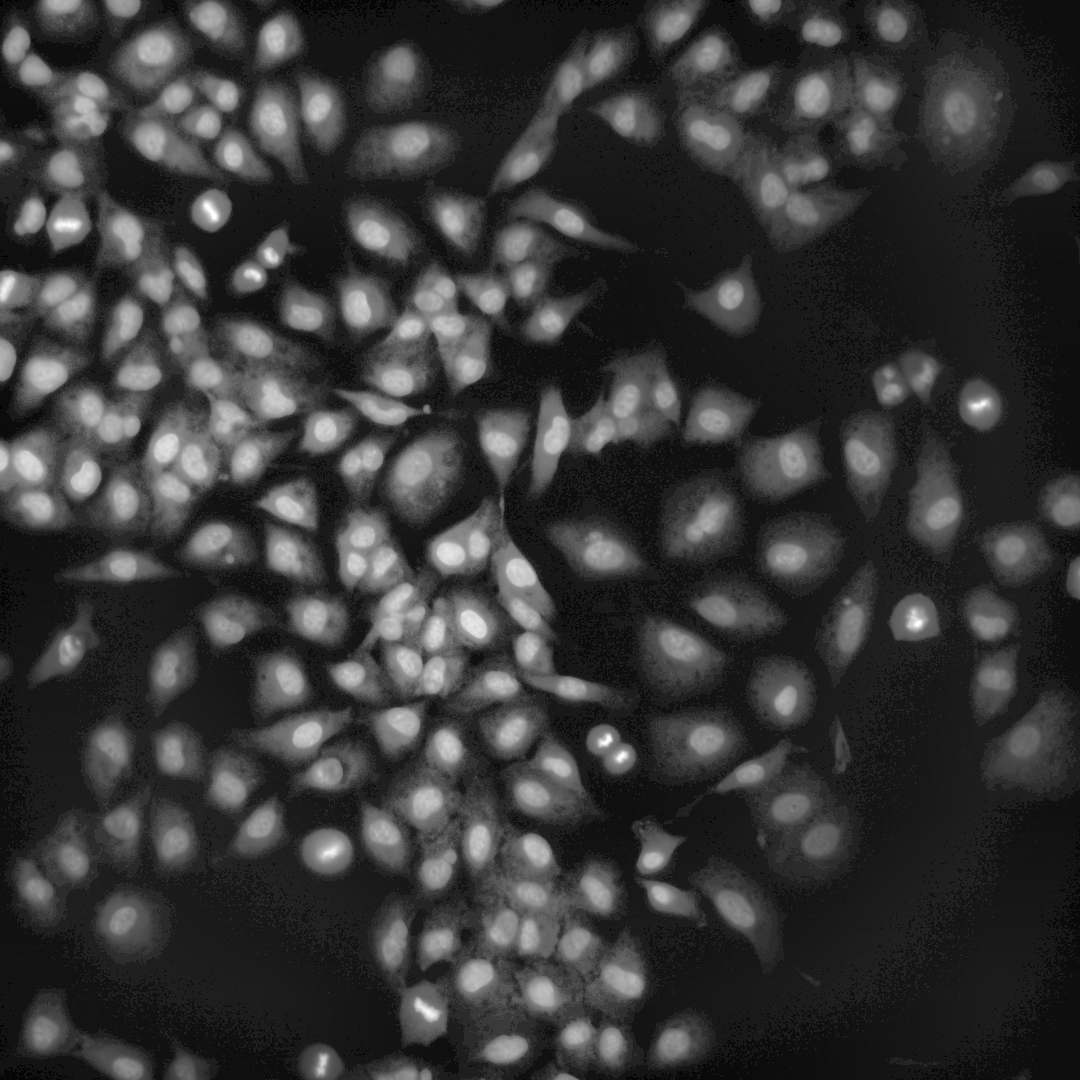
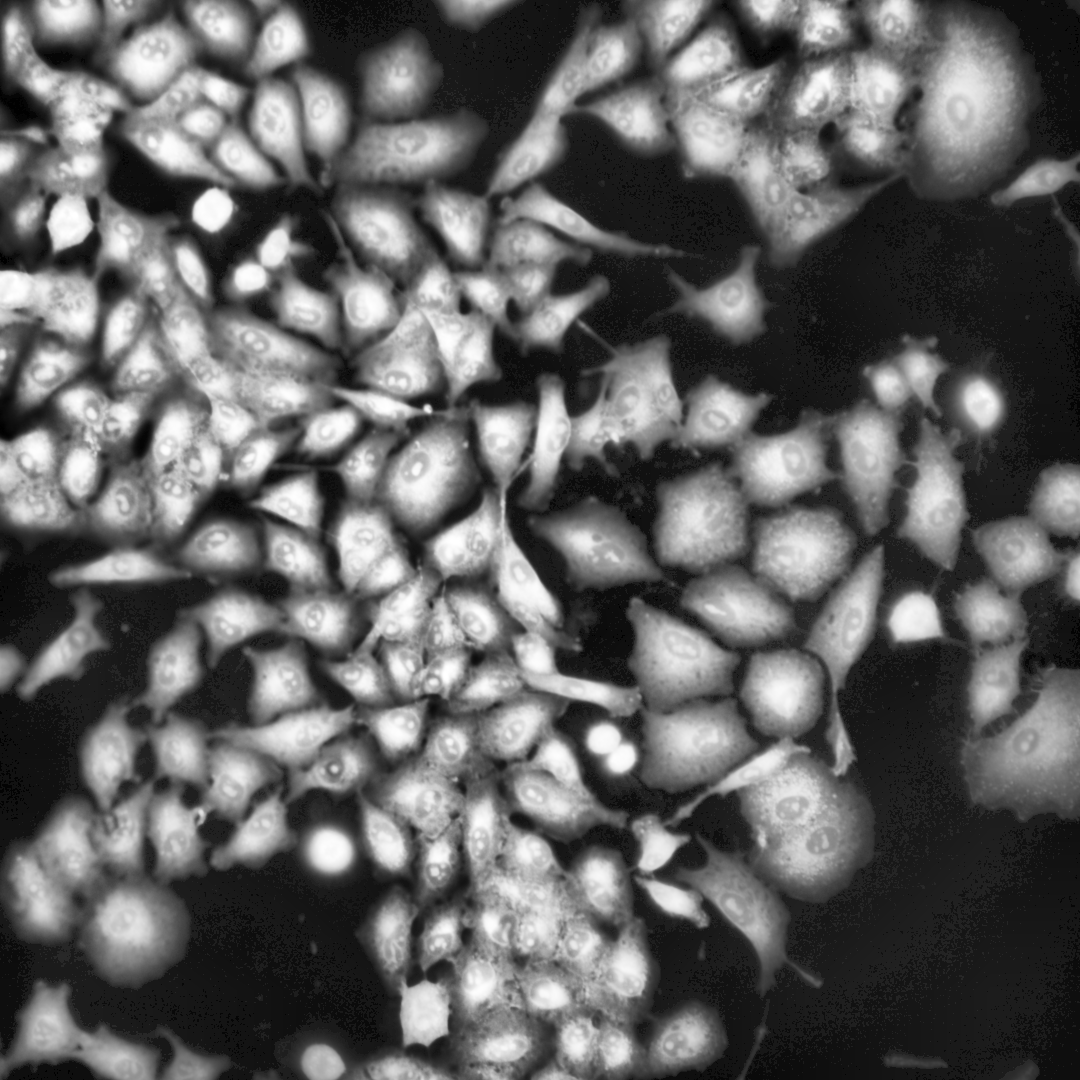
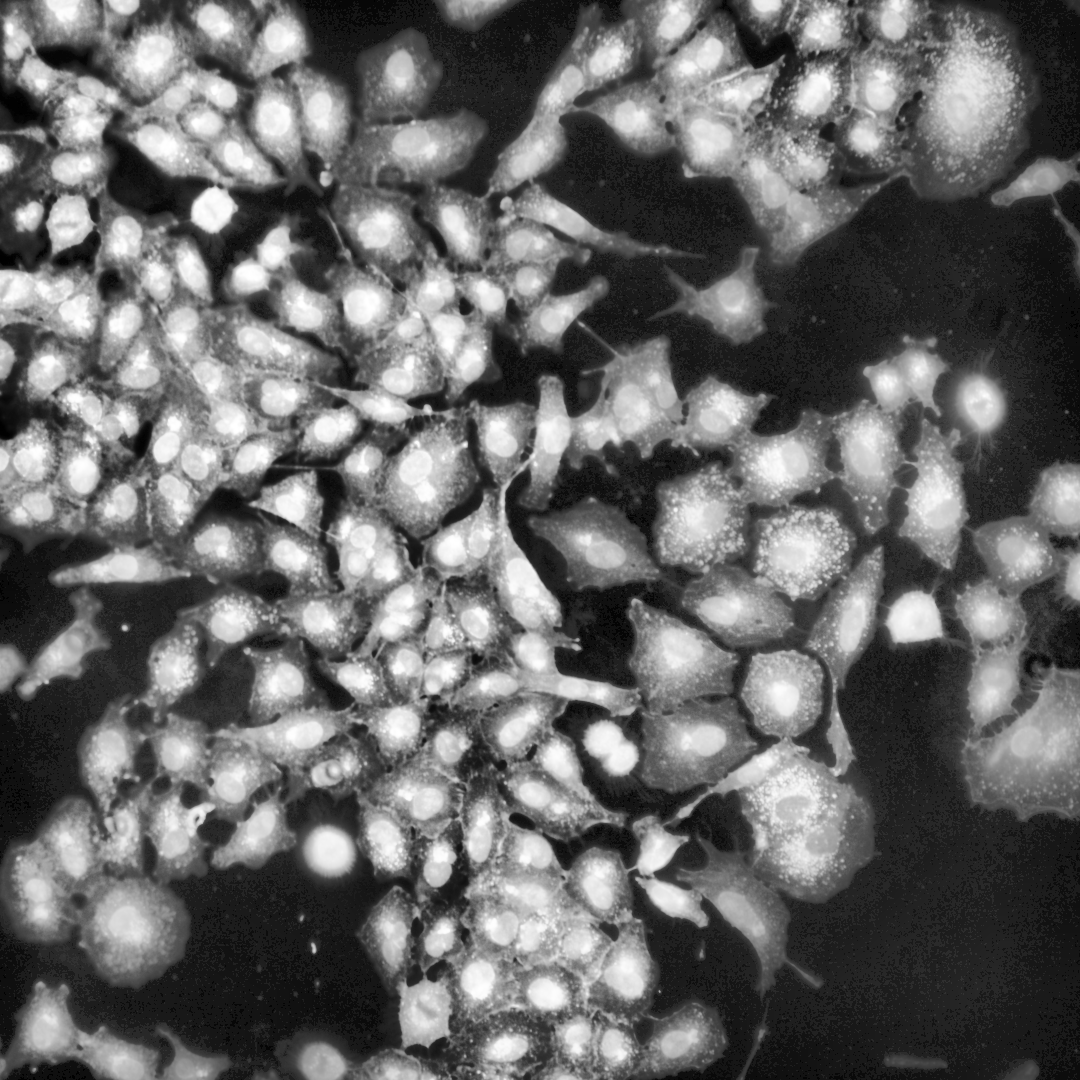
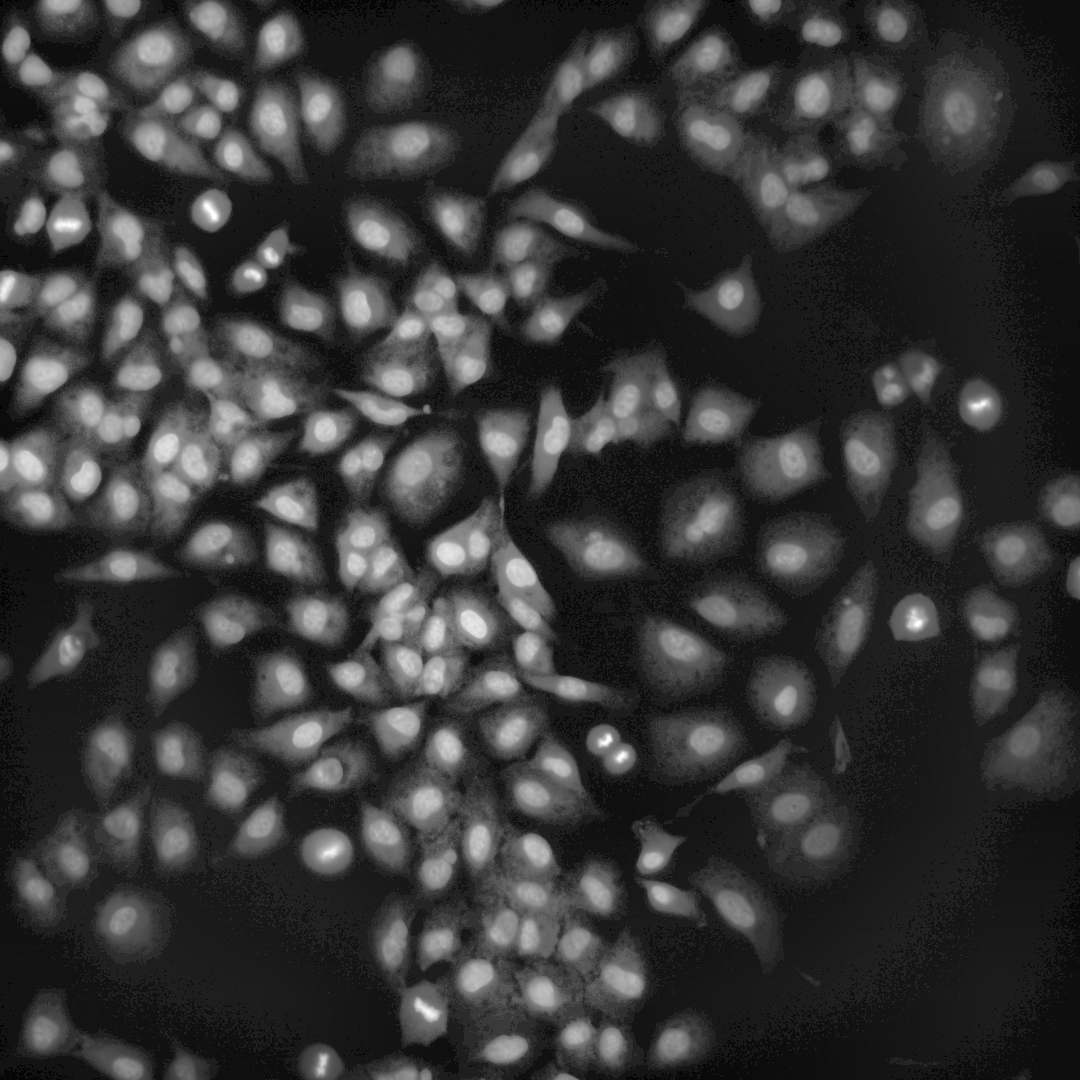
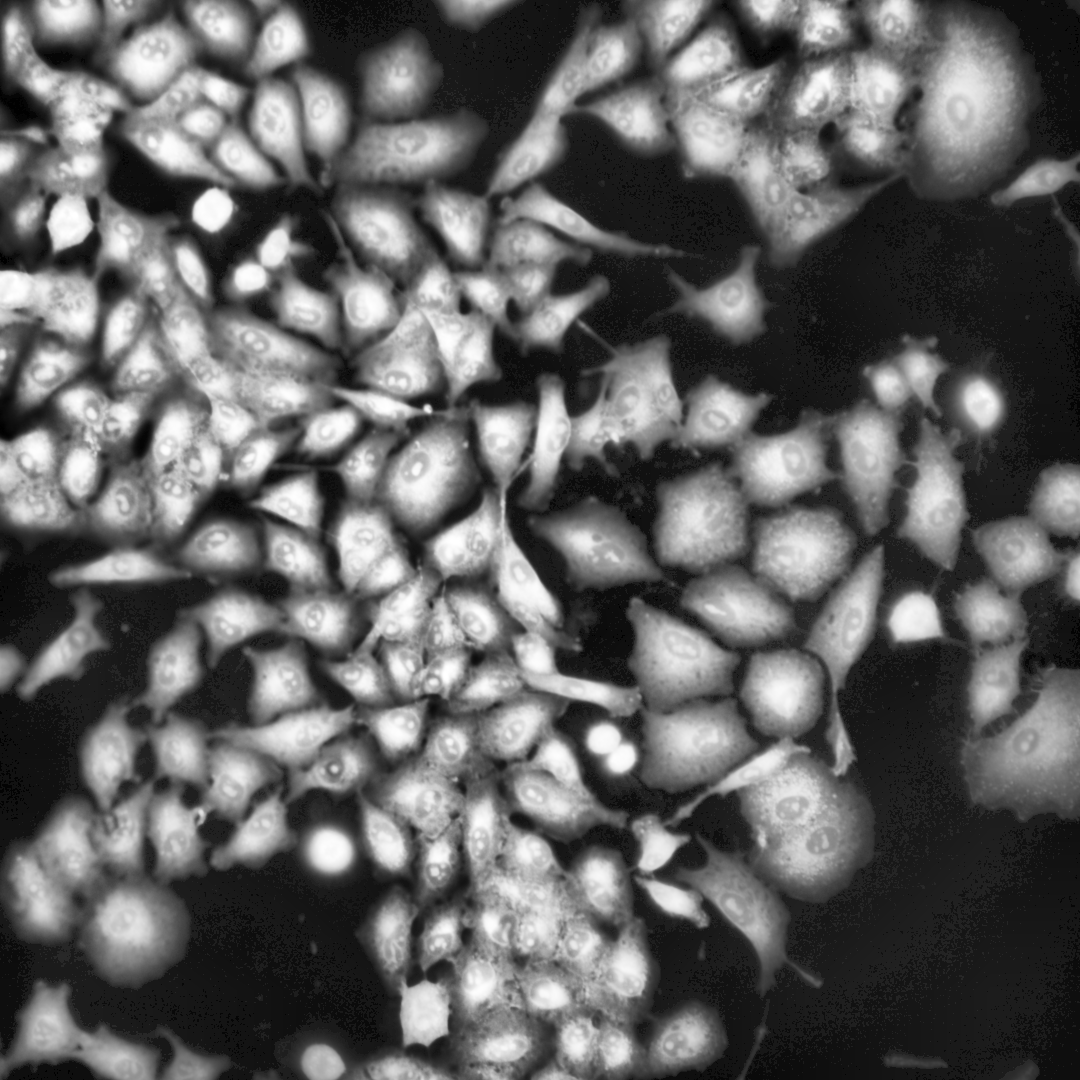
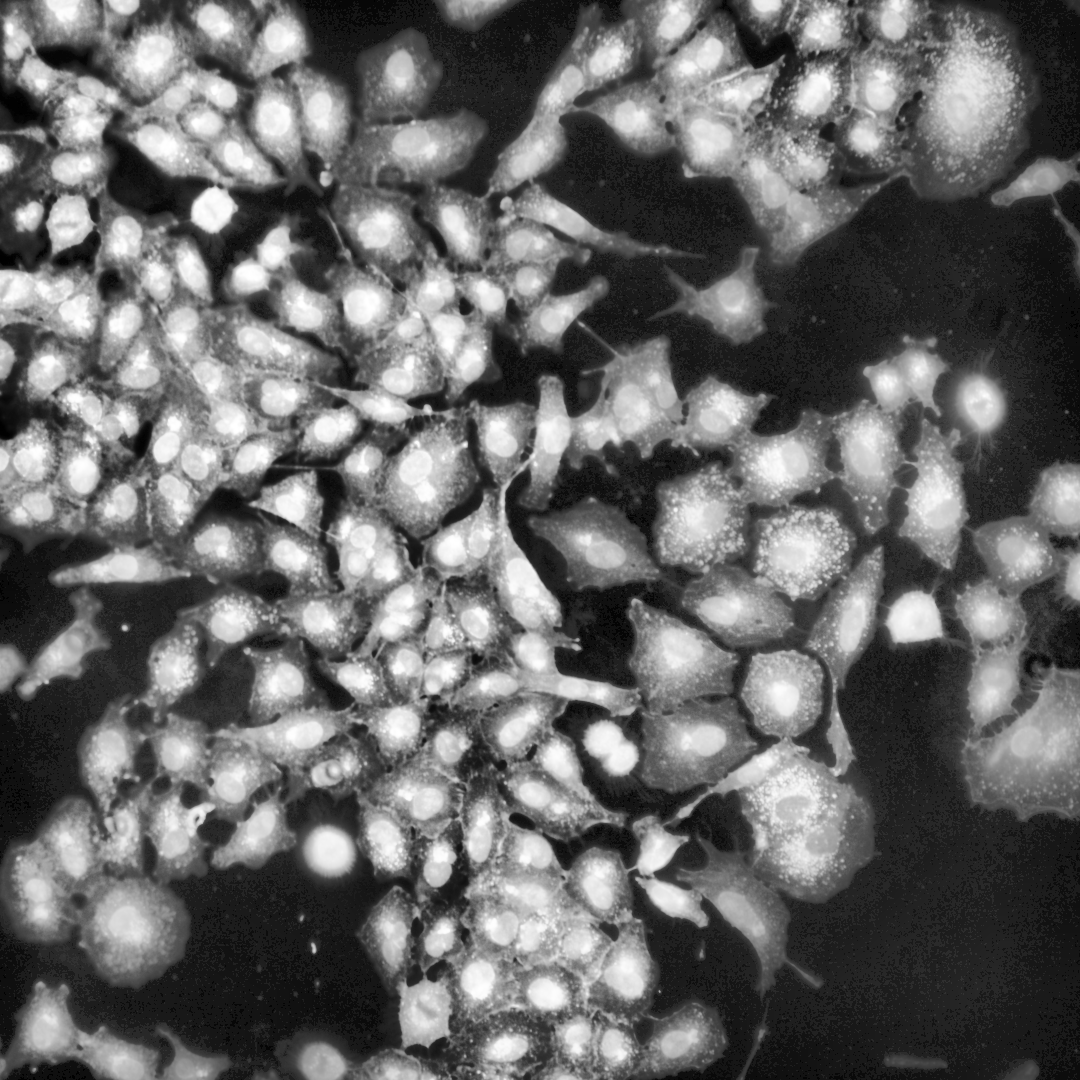
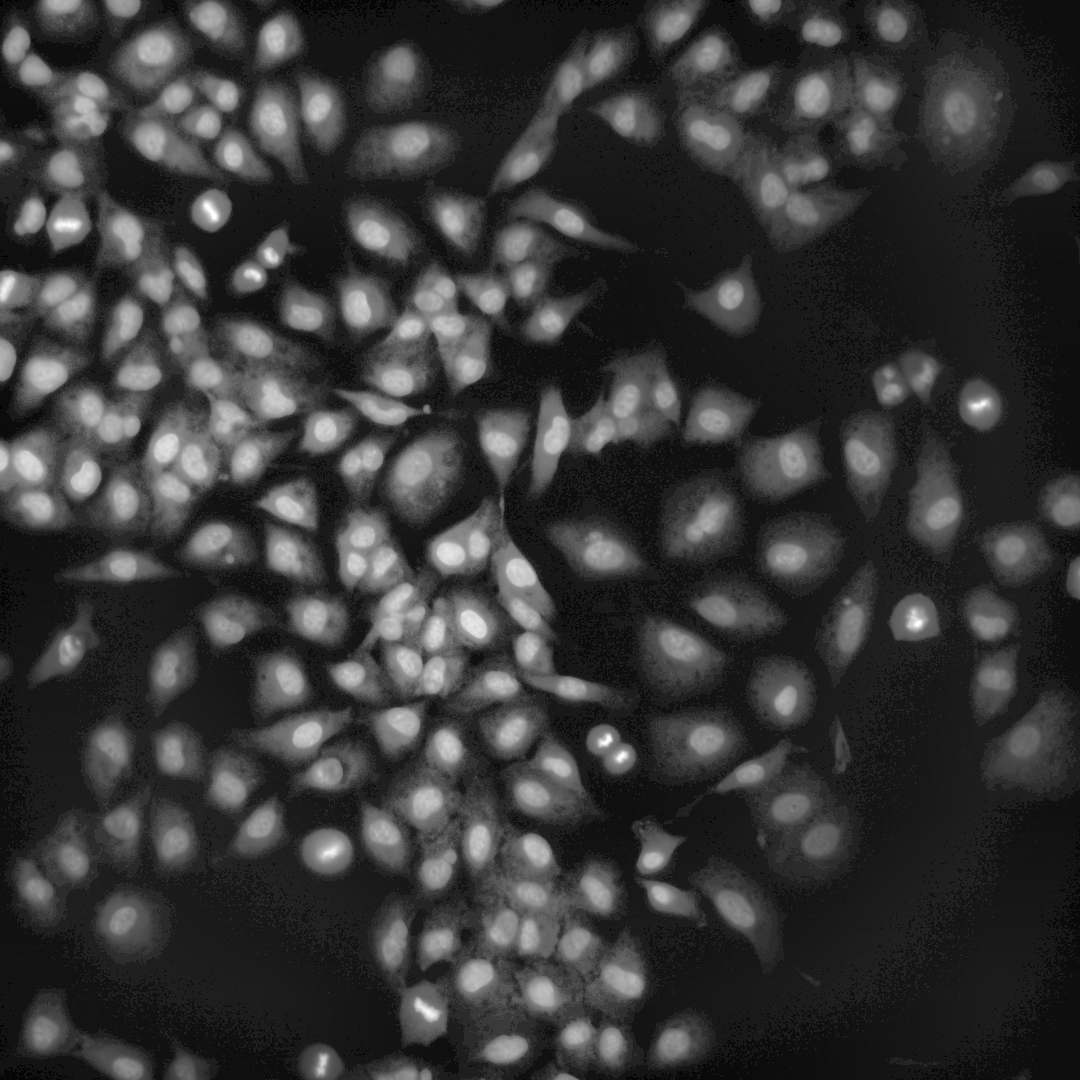
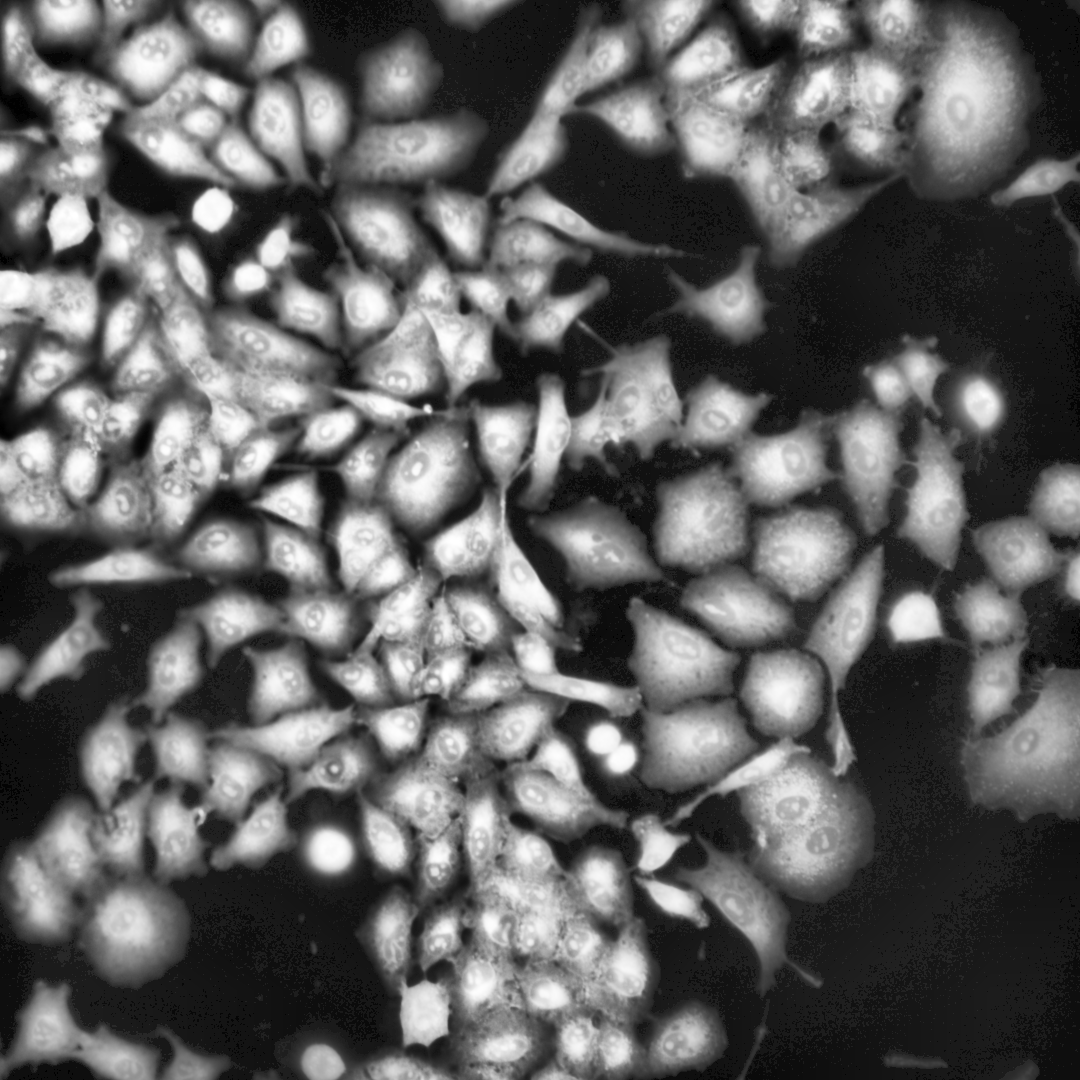

In [16]:
%%time
# For image-level data that has neither bounding box nor compartment center
# columns (for example, whole-image quality control metrics), use
# render_whole_image to display the full field of view without cropping.
jump_image_level = pd.read_parquet(f"{jump_data_path}/BR00117006_shrunken.parquet")
jump_image_level = jump_image_level.drop(
    columns=[
        column
        for column in jump_image_level.columns
        if "BoundingBox" in column or "Location_Center" in column
    ]
)
CytoDataFrame(
    data=jump_image_level,
    data_context_dir=f"{jump_data_path}/images/orig",
    display_options={"render_whole_image": True},
)[
    [
        "Metadata_ImageNumber",
        "Cells_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
        "Image_FileName_OrigRNA",
    ]
][:3]

CPU times: user 140 ms, sys: 35.4 ms, total: 175 ms
Wall time: 83.7 ms


,Metadata_ImageNumber,Metadata_Cells_Number_Object_Number,Image_FileName_GFP,Image_FileName_RFP,Image_FileName_DAPI
353,31,4,,,
1564,113,17,,,
1275,94,5,,,

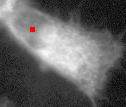
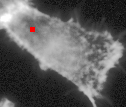
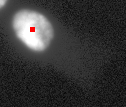
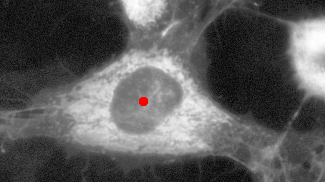
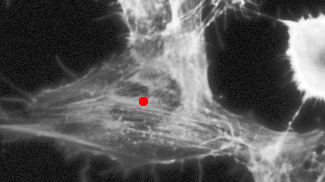
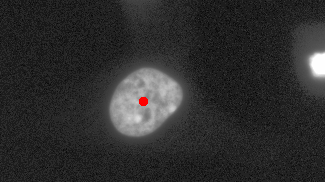
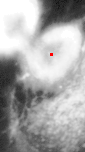
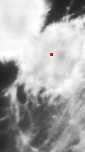
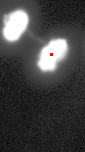

In [17]:
%%time
# view NF1 Cell Painting data with images
CytoDataFrame(
    data=f"{nf1_cellpainting_path}/Plate_2_with_image_data_shrunken.parquet",
    data_context_dir=f"{nf1_cellpainting_path}/Plate_2_images",
)[
    [
        "Metadata_ImageNumber",
        "Metadata_Cells_Number_Object_Number",
        "Image_FileName_GFP",
        "Image_FileName_RFP",
        "Image_FileName_DAPI",
    ]
][:3]

CPU times: user 145 ms, sys: 32.3 ms, total: 178 ms
Wall time: 77.6 ms


,Metadata_ImageNumber,Metadata_Cells_Number_Object_Number,Image_FileName_GFP,Image_FileName_RFP,Image_FileName_DAPI
353,31,4,,,
1564,113,17,,,
1275,94,5,,,

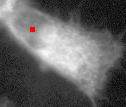
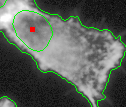
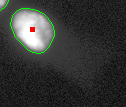
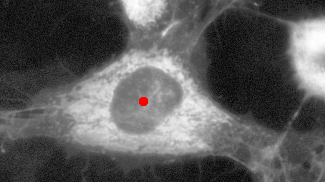
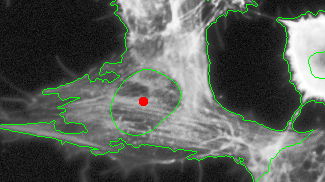
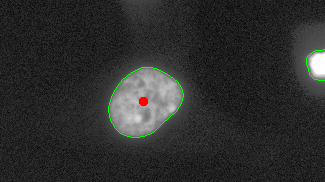
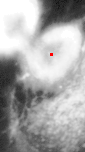
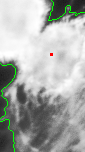
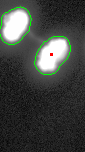

In [18]:
%%time
# view NF1 Cell Painting data with images and overlaid outlines from masks
frame = CytoDataFrame(
    data=f"{nf1_cellpainting_path}/Plate_2_with_image_data_shrunken.parquet",
    data_context_dir=f"{nf1_cellpainting_path}/Plate_2_images",
    data_mask_context_dir=f"{nf1_cellpainting_path}/Plate_2_masks",
)[
    [
        "Metadata_ImageNumber",
        "Metadata_Cells_Number_Object_Number",
        "Image_FileName_GFP",
        "Image_FileName_RFP",
        "Image_FileName_DAPI",
    ]
][:3]
frame

CPU times: user 149 ms, sys: 32.1 ms, total: 181 ms
Wall time: 76.6 ms


,Metadata_ImageNumber,Metadata_Cells_Number_Object_Number,Image_FileName_GFP,Image_FileName_RFP,Image_FileName_DAPI
353,31,4,,,
1564,113,17,,,
1275,94,5,,,

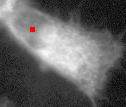
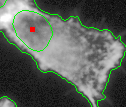
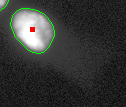
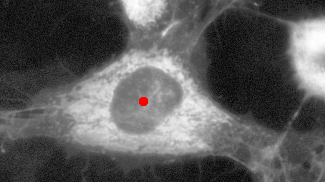
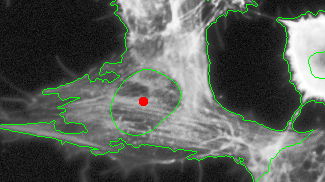
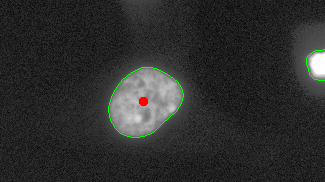
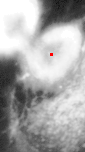
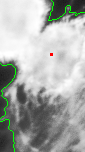
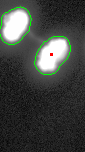

In [19]:
%%time
# add active paths on the local system to show how CytoDataFrame
# may be used without specifying a context directory for images.
# Note: normally these paths are local to the system where the
# profile data was generated, which often is not the same as the
# system which will be used to analyze the data.
parquet_path = f"{nf1_cellpainting_path}/Plate_2_with_image_data_shrunken.parquet"
nf1_dataset_with_modified_image_paths = pd.read_parquet(path=parquet_path)
nf1_dataset_with_modified_image_paths.loc[
    :, ["Image_PathName_DAPI", "Image_PathName_GFP", "Image_PathName_RFP"]
] = f"{pathlib.Path(parquet_path).parent}/Plate_2_images"

# view NF1 Cell Painting data with images and overlaid outlines from masks
CytoDataFrame(
    # note: we can read directly from an existing Pandas DataFrame
    data=nf1_dataset_with_modified_image_paths,
    data_mask_context_dir=f"{nf1_cellpainting_path}/Plate_2_masks",
)[
    [
        "Metadata_ImageNumber",
        "Metadata_Cells_Number_Object_Number",
        "Image_FileName_GFP",
        "Image_FileName_RFP",
        "Image_FileName_DAPI",
    ]
][:3]

CPU times: user 1.09 s, sys: 47.3 ms, total: 1.14 s
Wall time: 1.15 s


,Metadata_ImageNumber,Metadata_Cells_Number_Object_Number,Image_FileName_GFP,Image_FileName_RFP,Image_FileName_DAPI,Image_FileName_GFP_OMEArrow_ORIG,Image_FileName_GFP_OMEArrow_LABL,Image_FileName_GFP_OMEArrow_COMP,Image_FileName_RFP_OMEArrow_ORIG,Image_FileName_RFP_OMEArrow_LABL,Image_FileName_RFP_OMEArrow_COMP,Image_FileName_DAPI_OMEArrow_ORIG,Image_FileName_DAPI_OMEArrow_LABL,Image_FileName_DAPI_OMEArrow_COMP
353,31,4,B7_01_2_3_GFP_001.tif,B7_01_3_3_RFP_001.tif,B7_01_1_3_DAPI_001.tif,,None,,,,,,,
1564,113,17,H12_01_2_1_GFP_001.tif,H12_01_3_1_RFP_001.tif,H12_01_1_1_DAPI_001.tif,,None,,,,,,,
1275,94,5,F7_01_2_2_GFP_001.tif,F7_01_3_2_RFP_001.tif,F7_01_1_2_DAPI_001.tif,,None,,,,,,,

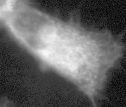
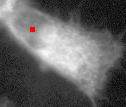
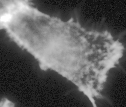
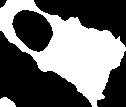
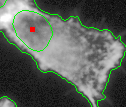
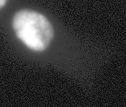
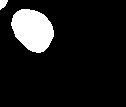
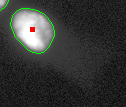
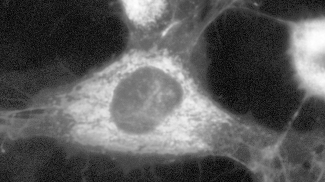
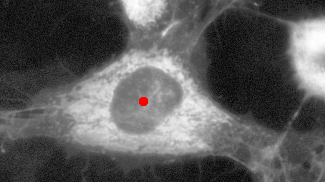
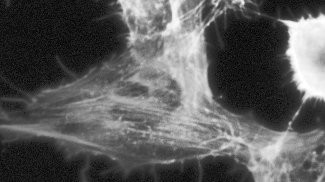
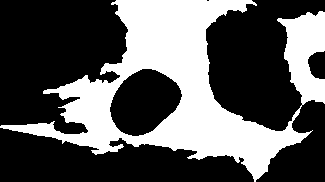
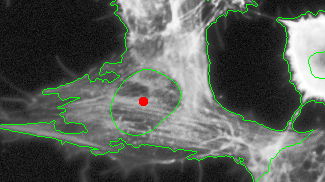
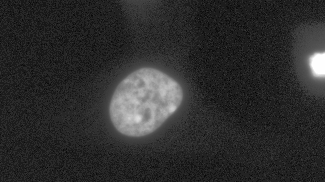
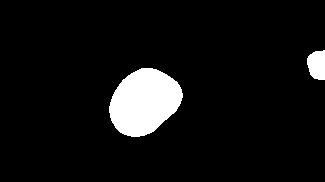
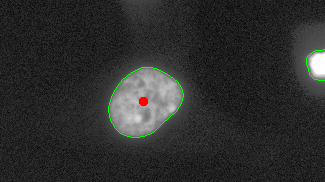
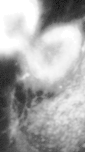
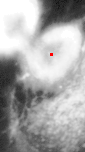
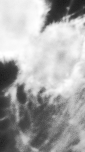
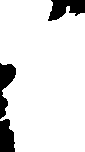
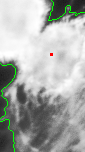
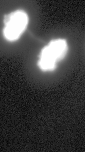
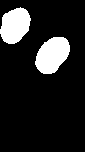
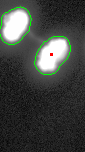

In [20]:
%%time
# export to OME Parquet, a format which uses OME Arrow
# to store OME-spec images as values within the table.
frame.to_ome_parquet(file_path="example.ome.parquet")

# read OME Parquet file into the CytoDataFrame
CytoDataFrame(data="example.ome.parquet")

CPU times: user 68.3 ms, sys: 14.2 ms, total: 82.4 ms
Wall time: 40 ms


,Metadata_ImageNumber,Nuclei_Number_Object_Number,Image_FileName_A647,Image_FileName_DAPI,Image_FileName_GOLD
0,1,1,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
1,1,2,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
2,1,3,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff

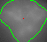
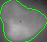

In [21]:
%%time
# view nuclear speckles data with images and overlaid outlines from masks
CytoDataFrame(
    data=f"{nuclear_speckles_path}/test_slide1_converted.parquet",
    data_context_dir=f"{nuclear_speckles_path}/images/plate1",
    data_mask_context_dir=f"{nuclear_speckles_path}/masks/plate1",
)[
    [
        "Metadata_ImageNumber",
        "Nuclei_Number_Object_Number",
        "Image_FileName_A647",
        "Image_FileName_DAPI",
        "Image_FileName_GOLD",
    ]
][:3]

CPU times: user 60.8 ms, sys: 19.2 ms, total: 79.9 ms
Wall time: 37.7 ms


,Metadata_ImageNumber,Nuclei_Number_Object_Number,Nuclei_Texture_Variance_DAPI_3_03_256,Image_FileName_A647,Image_FileName_DAPI,Image_FileName_GOLD
0,1,1,2.484139,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
1,1,2,12.026326,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
2,1,3,51.418746,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
3,1,4,47.049561,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
4,1,5,117.135912,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
5,1,6,25.371580,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
6,1,7,23.930735,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
7,1,8,2.973642,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
8,1,9,8.355843,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff
9,1,10,150.652194,slide1_A1_M10_CH1_Z09_illumcorrect.tiff,,slide1_A1_M10_CH2_Z09_illumcorrect.tiff

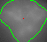
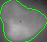
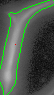
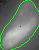
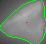
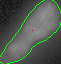
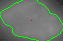
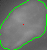
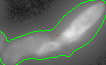
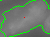
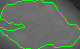
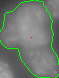
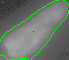
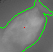
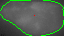
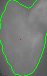
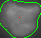
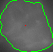
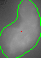
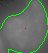
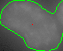
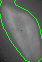
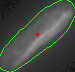

In [22]:
%%time
# view nuclear speckles data with images and overlaid outlines from masks
# and also apply a filter to only show rows where the value for
# "Nuclei_Texture_Variance_DAPI_3_03_256".
CytoDataFrame(
    data=f"{nuclear_speckles_path}/test_slide1_converted.parquet",
    data_context_dir=f"{nuclear_speckles_path}/images/plate1",
    data_mask_context_dir=f"{nuclear_speckles_path}/masks/plate1",
    display_options={
        "filter_columns": ["Nuclei_Texture_Variance_DAPI_3_03_256"],
    },
)[
    [
        "Metadata_ImageNumber",
        "Nuclei_Number_Object_Number",
        "Nuclei_Texture_Variance_DAPI_3_03_256",
        "Image_FileName_A647",
        "Image_FileName_DAPI",
        "Image_FileName_GOLD",
    ]
]

CPU times: user 188 ms, sys: 47.6 ms, total: 236 ms
Wall time: 79.3 ms


,Metadata_ImageNumber,Metadata_Nuclei_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA
0,3,3,,
1,3,4,,
2,3,6,,
3,3,7,,
4,3,8,,

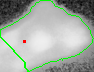
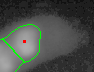
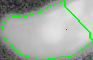
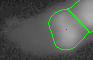
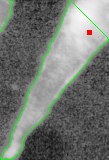
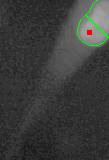
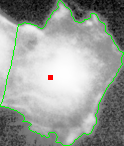
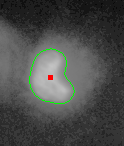
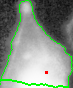
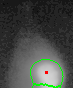

In [23]:
%%time
# view ALSF pediatric cancer atlas plate BR00143976 with images
cdf = CytoDataFrame(
    data=f"{pediatric_cancer_atlas_path}/BR00143976_shrunken.parquet",
    data_context_dir=f"{pediatric_cancer_atlas_path}/images/orig",
    data_outline_context_dir=f"{pediatric_cancer_atlas_path}/images/outlines",
    segmentation_file_regex={
        r"CellsOutlines_BR(\d+)_C(\d{2})_\d+\.tiff": r".*ch3.*\.tiff",
        r"NucleiOutlines_BR(\d+)_C(\d{2})_\d+\.tiff": r".*ch5.*\.tiff",
    },
)[
    [
        "Metadata_ImageNumber",
        "Metadata_Nuclei_Number_Object_Number",
        "Image_FileName_OrigAGP",
        "Image_FileName_OrigDNA",
    ]
]
cdf

In [24]:
%%time
# show that we can use the cytodataframe again
# by quick variable reference.
cdf

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 4.77 μs


CPU times: user 734 ms, sys: 63.8 ms, total: 797 ms
Wall time: 717 ms


,Metadata_ImageNumber,Metadata_Nuclei_Number_Object_Number,Image_FileName_OrigAGP,Image_FileName_OrigDNA,Image_FileName_OrigAGP_OMEArrow_ORIG,Image_FileName_OrigAGP_OMEArrow_LABL,Image_FileName_OrigAGP_OMEArrow_COMP,Image_FileName_OrigDNA_OMEArrow_ORIG,Image_FileName_OrigDNA_OMEArrow_LABL,Image_FileName_OrigDNA_OMEArrow_COMP
0,3,3,r03c03f03p01-ch3sk1fk1fl1.tiff,r03c03f03p01-ch5sk1fk1fl1.tiff,,,,,,
1,3,4,r03c03f03p01-ch3sk1fk1fl1.tiff,r03c03f03p01-ch5sk1fk1fl1.tiff,,,,,,
2,3,6,r03c03f03p01-ch3sk1fk1fl1.tiff,r03c03f03p01-ch5sk1fk1fl1.tiff,,,,,,
3,3,7,r03c03f03p01-ch3sk1fk1fl1.tiff,r03c03f03p01-ch5sk1fk1fl1.tiff,,,,,,
4,3,8,r03c03f03p01-ch3sk1fk1fl1.tiff,r03c03f03p01-ch5sk1fk1fl1.tiff,,,,,,

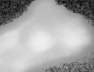
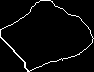
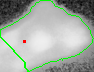
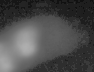
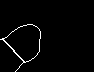
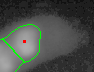
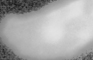
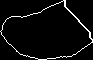
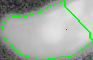
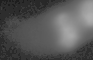
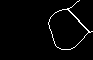
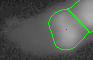
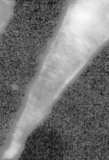
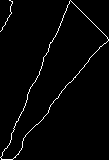
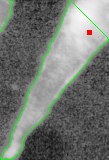
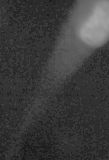
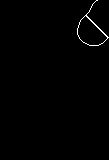
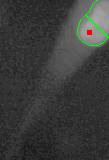
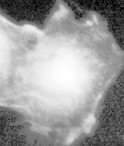
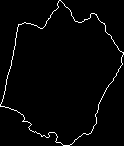
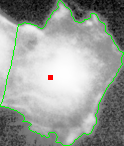
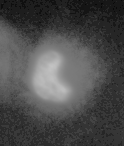
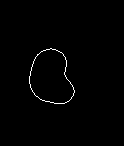
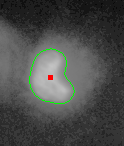
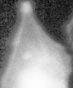
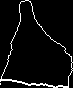
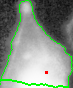
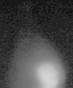
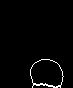
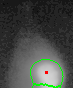

In [25]:
%%time
# export to OME Parquet, a format which uses OME Arrow
# to store OME-spec images as values within the table.
cdf.to_ome_parquet(file_path="example.ome.parquet")

# read OME Parquet file into the CytoDataFrame
CytoDataFrame(data="example.ome.parquet")

CPU times: user 8.17 ms, sys: 2.3 ms, total: 10.5 ms
Wall time: 9.21 ms


GridspecLayout(children=(HTML(value="<div style='width:100%;height:100%;background:#EBEBEB;padding:5px 4px 5px…

,ImageNumber,ObjectNumber,FileName_Nuclei
0,1,1,
1,1,2,
2,1,3,

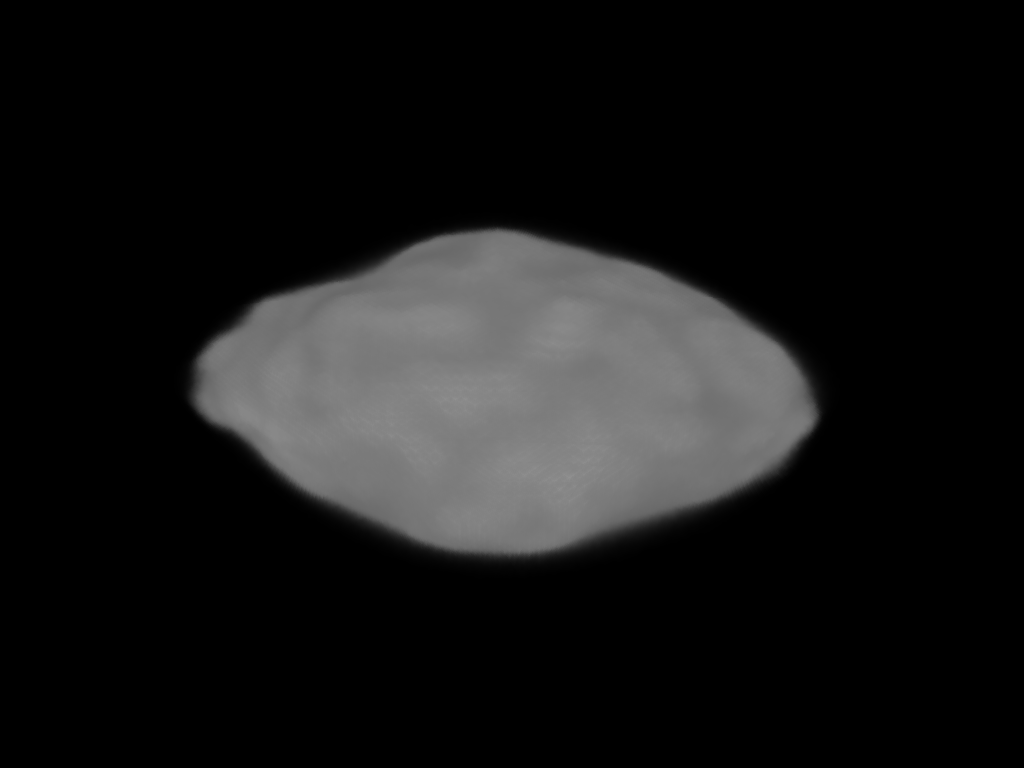
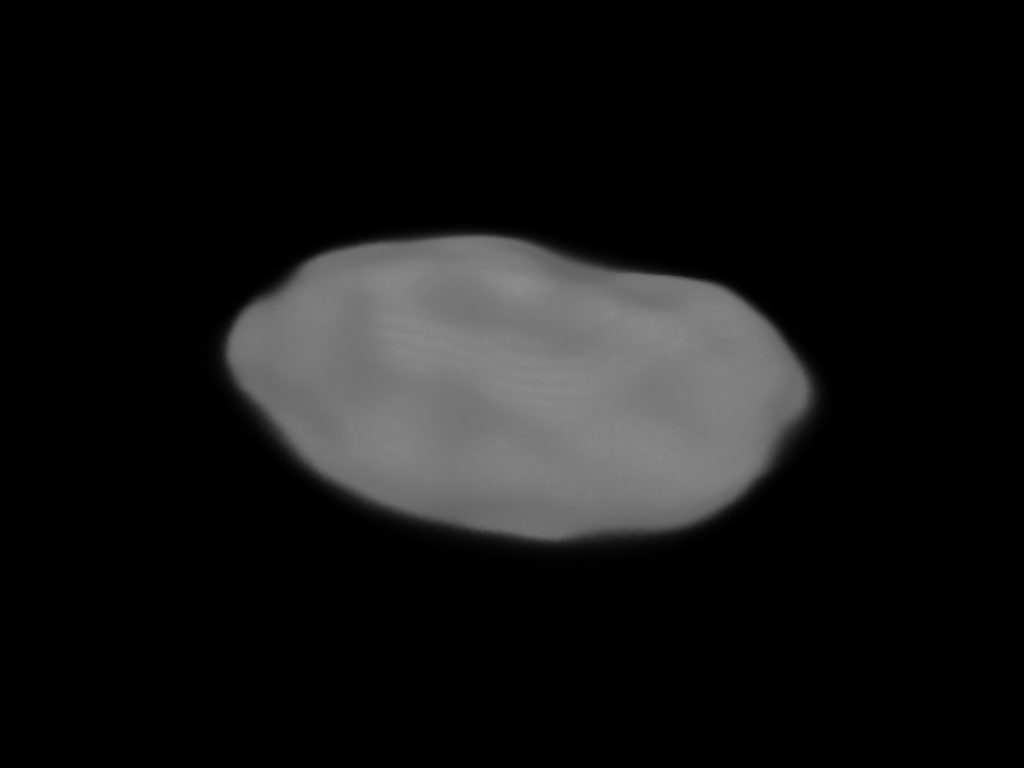
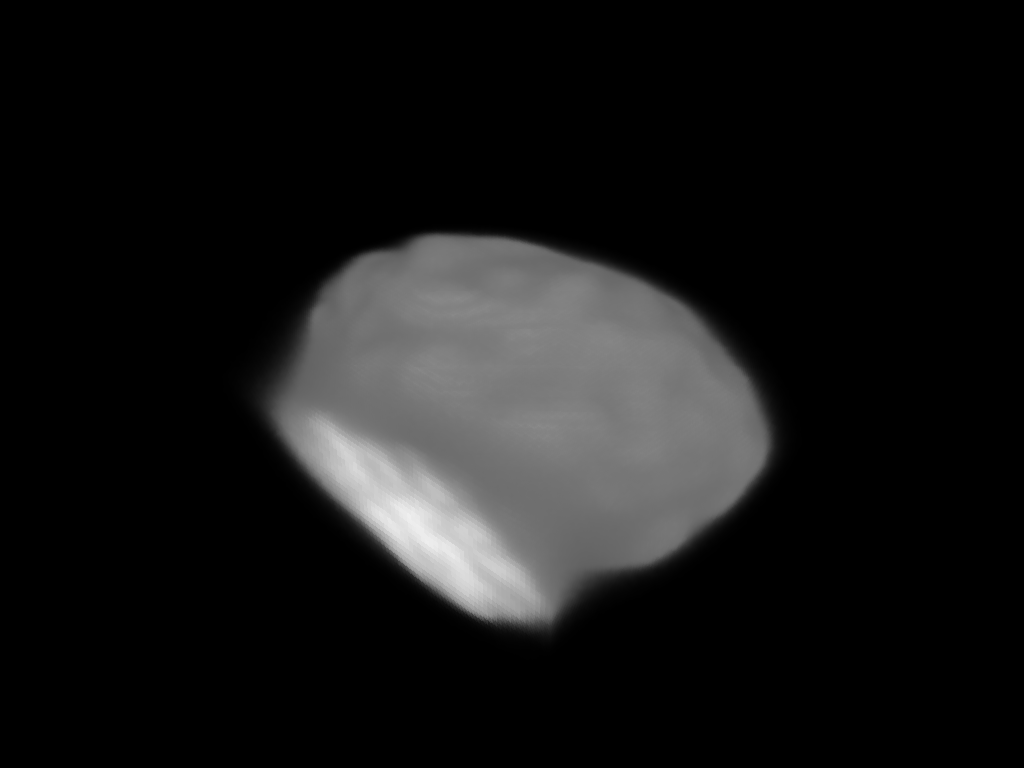

In [26]:
%%time
# 3D example dataset, showing how
# CytoDataFrame can be used with 3D data for visualization.
cp_3d_path = "../../../tests/data/CP_tutorial_3D_noise_nuclei_segmentation"

# send the data to CytoDataFrame
# note: because we have 3d input images, CytoDataFrame will automatically process
# using the 3D display options for interactive visualization.
cdf = CytoDataFrame(
    data=pathlib.Path(cp_3d_path) / "output/MyExpt_RealsizeNuclei.csv",
    data_context_dir=str(pathlib.Path(cp_3d_path) / "input"),
)

cdf[["ImageNumber", "ObjectNumber", "FileName_Nuclei"]][:3]

CPU times: user 10.4 ms, sys: 2.97 ms, total: 13.4 ms
Wall time: 11.6 ms


GridspecLayout(children=(HTML(value="<div style='width:100%;height:100%;background:#EBEBEB;padding:5px 4px 5px…

,ImageNumber,ObjectNumber,FileName_Nuclei
0,1,1,
1,1,2,
2,1,3,

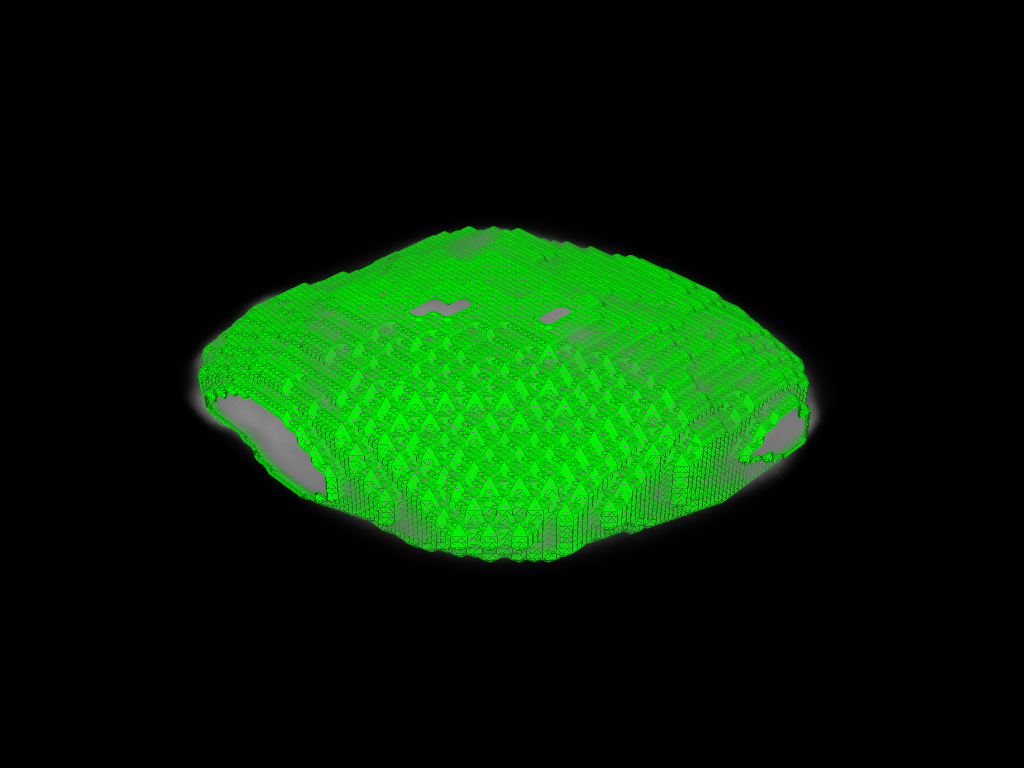
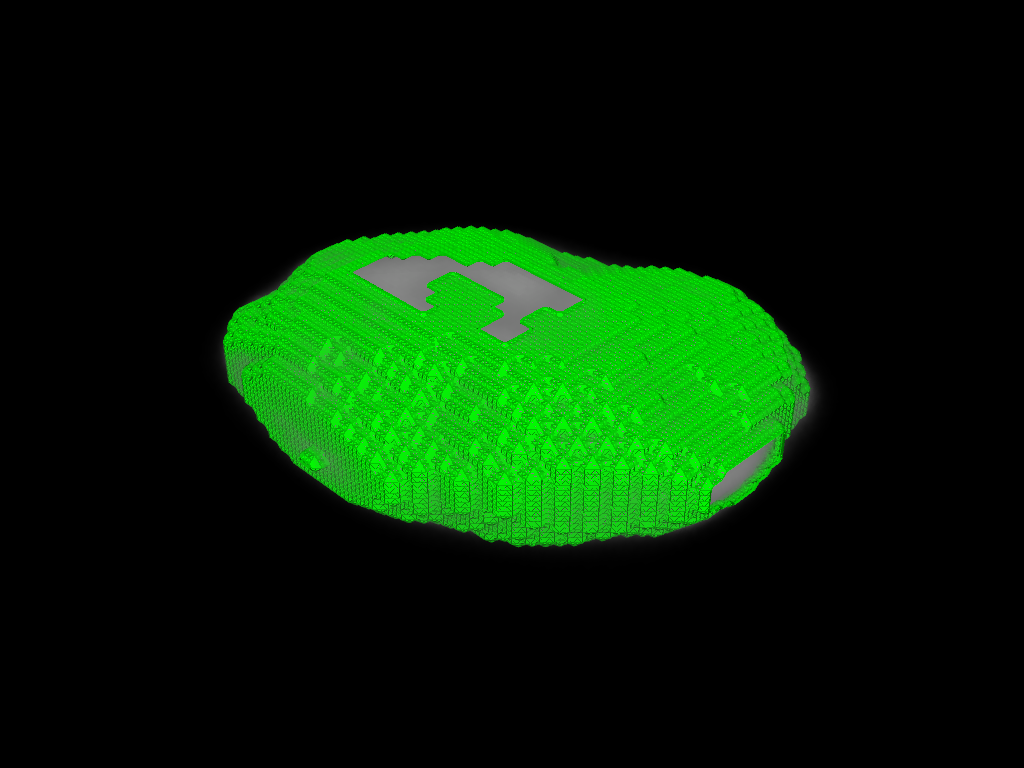
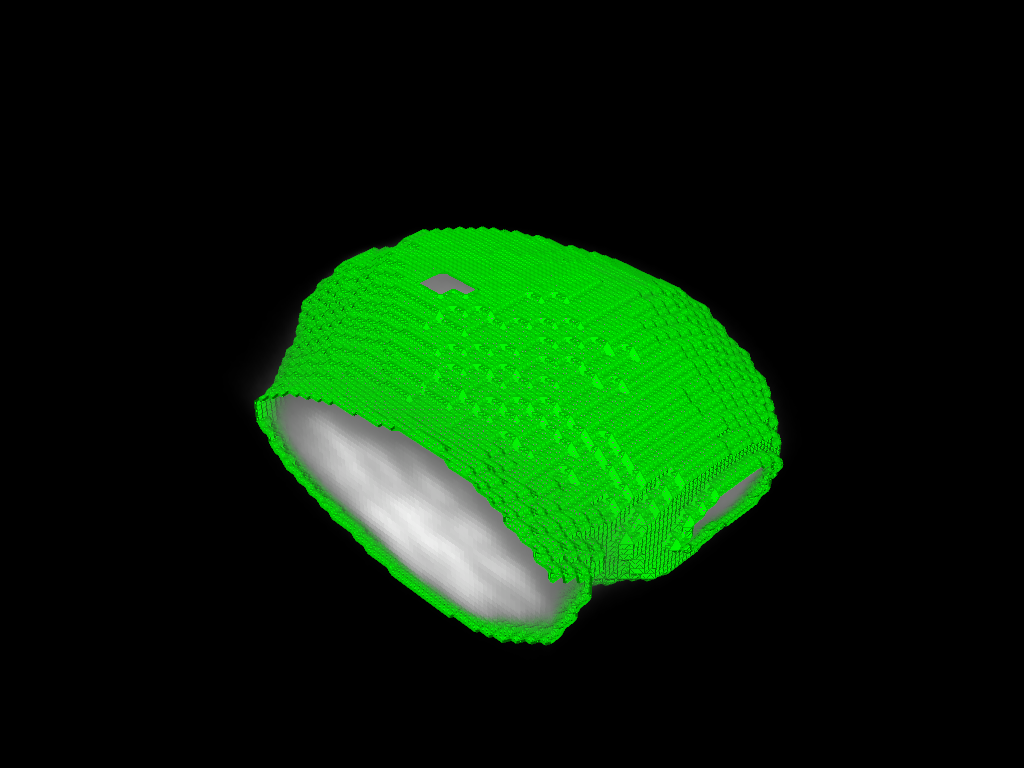

In [27]:
%%time
# read 3d images with segmentation masks and show the
# segmentation masks are also 3D.
cdf = CytoDataFrame(
    data=pathlib.Path(cp_3d_path) / "output/MyExpt_RealsizeNuclei.csv",
    data_context_dir=str(pathlib.Path(cp_3d_path) / "input"),
    data_mask_context_dir=str(pathlib.Path(cp_3d_path) / "output/masks"),
)

cdf[["ImageNumber", "ObjectNumber", "FileName_Nuclei"]][:3]